# The Fabry-Perot Etalon
It is an optical cavity made from two parallel reflecting surfaces (i.e., thin mirrors). Optical waves can pass through the optical cavity only when they are in resonance with it.

<p align="center">
  <img src="fabry_perot_setup.png" alt="Fabry-Perot Interferometer Setup">
</p>

The cavity is defined by a propagation length $L$ in vacuum, amplitude reflectivities $r_1$ and $r_2$, and amplitude transmittivities $t_1$ and $t_2$ for the two mirrors. The optical field amplitudes at different points inside the cavity can be obtained through the superposition of reflected and transmitted fields.

The reflected field from the cavity is obtained as
$$
    \boxed{a_4=a_0\frac{r_1-r_2(r_1^2+t_1^2)e^{-i2kL}}{1-r_1 r_2 e^{-i2kL}}}
$$

while the transmitted field becomes

$$
\boxed{a_2=a_0\frac{-t_1 t_2 e^{-ikL}}{1-r_1 r_2 e^{-i2kL}}}
$$

The circulating optical power inside the cavity depends strongly on the laser frequency. Maximum intracavity power occurs when the denominator of the cavity response becomes minimum. This happens when the round-trip phase accumulated by the optical field is an integer multiple of $2\pi$. The resonance condition is therefore $2L = N\lambda$, where $N$ is an integer and $\lambda$ is the wavelength of the injected light.

Using the relation, $k=\frac{2\pi}{\lambda}$ the resonance condition can be rewritten as: 
$2L = \frac{N2\pi}{k} \implies \boxed{kL = N\pi}$

Minimum circulating power occurs at anti-resonance, where
$kL = \left(N+\frac{1}{2}\right)\pi$
corresponding to destructive interference between successive round-trip fields.

---
## Free Spectral Range

The phase accumulated during a round trip can also be written as: 
$2kL=\frac{\omega 2L}{c}=2\pi f \frac{2L}{c}=2\pi \frac{f}{\text{FSR}}$
where the quantity
$
\boxed{\text{FSR}=\frac{c}{2L}}
$
is called the **free spectral range** of the cavity. The free spectral range represents the frequency spacing between adjacent cavity resonances. Resonance therefore occurs at frequencies,
$
f_r = N\cdot \text{FSR}
$
with $N$ being an integer.

---
## Linewidth

Another important characteristic of the cavity is its linewidth, usually specified by its full width at half maximum (FWHM) or equivalently by the pole frequency $f_p$. The linewidth is determined by the frequency at which the circulating power falls to half of its maximum value. This yields the full linewidth expression

$$
\boxed{\text{FWHM}
=
2f_p
=
\frac{2\text{FSR}}{\pi}
\arcsin
\left(
\frac{1-r_1 r_2}{2\sqrt{r_1 r_2}}
\right)}
$$

---
## Finesse

The ratio of the free spectral range to the linewidth defines the cavity finesse:

$$
\boxed{\mathcal{F}
=
\frac{\text{FSR}}{\text{FWHM}}
=
\frac{\pi}{
2\arcsin
\left(
\frac{1-r_1 r_2}{2\sqrt{r_1 r_2}}
\right)
}}
$$

The finesse of a cavity is its quality factor. The finesse measures the sharpness of the cavity resonance peaks. High finesse cavities exhibit narrow resonances and large intracavity power buildup.

For highly reflective mirrors where $r_1 \approx 1$, and $r_2 \approx 1$, the argument of the arcsine function becomes small, allowing the approximation

$$
\mathcal{F}
\approx
\frac{\pi\sqrt{r_1 r_2}}{1-r_1 r_2}
\approx
\frac{\pi}{1-r_1 r_2}
$$

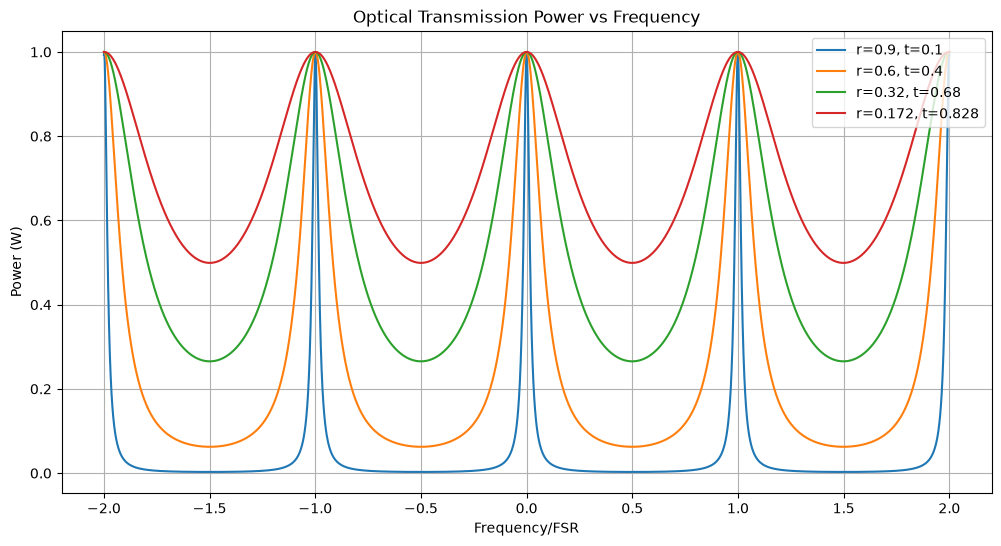

In [19]:
import finesse
from finesse import Model
from finesse.analysis.actions import Xaxis
import matplotlib.pyplot as plt

model1 = Model()
model1.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.9 T=0.1     # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.9 T=0.1      # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out1 = model1.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

model2 = Model()
model2.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.6 T=0.4     # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.6 T=0.4      # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out2 = model2.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

model3 = Model()
model3.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.32 T=0.68     # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.32 T=0.68      # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out3 = model3.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

model4 = Model()
model4.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.172 T=0.828     # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.172 T=0.828      # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out4 = model4.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

plt.figure(figsize=(12, 6))
plt.plot(out1.x[0]/FSR, out1['trans'], label='r=0.9, t=0.1')
plt.plot(out2.x[0]/FSR, out2['trans'], label='r=0.6, t=0.4')
plt.plot(out3.x[0]/FSR, out3['trans'], label='r=0.32, t=0.68')
plt.plot(out4.x[0]/FSR, out4['trans'], label='r=0.172, t=0.828')
plt.xlabel('Frequency/FSR')
plt.ylabel('Power (W)')
plt.title('Optical Transmission Power vs Frequency')
plt.legend()
plt.grid()
plt.show()

In [20]:
import numpy as np
c = 3e8                                                 # speed of light ( m / s )
L = 3000                                                # cavity length ( m )
R1 = 0.9; R2 = 0.9
FSR = c / (2 * L) # FSR
F = (np . pi * np . sqrt ( R1 * R2 ) ) / (1 - R1 * R2)  # Finesse
linewidth = FSR / F                                     # Linewidth

print(f"FSR: {FSR:.2f} Hz")
print(f"Finesse: {F:.2f}")
print(f"Linewidth: {linewidth:.2f} Hz")

FSR: 50000.00 Hz
Finesse: 14.88
Linewidth: 3359.94 Hz


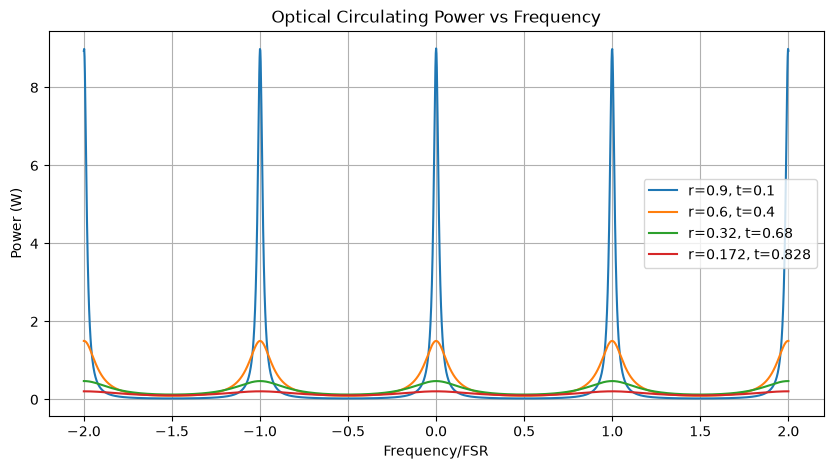

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(out1.x[0]/FSR, out1['circ'], label='r=0.9, t=0.1')
plt.plot(out2.x[0]/FSR, out2['circ'], label='r=0.6, t=0.4')
plt.plot(out3.x[0]/FSR, out3['circ'], label='r=0.32, t=0.68')
plt.plot(out4.x[0]/FSR, out4['circ'], label='r=0.172, t=0.828')
plt.xlabel('Frequency/FSR')
plt.ylabel('Power (W)')
plt.title('Optical Circulating Power vs Frequency')
plt.legend()
plt.grid()
plt.show()

# The Lorentzian
The optical field stored inside the cavity decays exponentially after the input field is removed. For a resonant cavity mode of frequency $\nu_q$, the electric field evolves as

$$E_q(t)=E_{q,s}e^{i2\pi\nu_q t}e^{-t/(2\tau_c)}$$

Exponential decay in time implies that the cavity's spectral response is no longer infinitely sharp. Taking the Fourier transform $\tilde{E}(\nu)=\int^\infty_0 dt\,E(t)e^{-i2\pi\nu t} \ \text{where,} \ E(t)=E_Se^{-t/2\tau_c}e^{i2\pi\nu_qt}$. of the exponentially decaying field yields a Lorentzian frequency response,

$$\tilde{E}_q(\nu)
=
\frac{E_{q,s}}
{(2\tau_c)^{-1}+i2\pi(\nu-\nu_q)}$$

The corresponding *normalised* power spectrum is

$$\tilde{\gamma}_q(\nu) = \frac{1}{\tau_c} \left| \frac{\tilde{E}_q(\nu)}{E_{q,s}} \right|^2 = \frac{1}{\tau_c} \frac{1}{(2\tau_c)^{-2} + 4\pi^2 (\nu - \nu_q)^2}$$

which has the characteristic Lorentzian\footnote{The standard Lorentzian centered at $x=x_0$ is $L(x)=\frac{A}{(x-x_0)^2+\Gamma^2}$, where $A$ controls the height, and
$\Gamma$ is the half-width.} profile, whose frequency integral is unity. 

---

## Lorentzian Linewidth
Introducing the full width at half maximum (FWHM) linewidth $\Delta\nu_c$ of the Lorentzian spectral line shape, we obtain

$$\Delta\nu_c = \frac{1}{2\pi\tau_c} \implies \boxed{ \tilde{\gamma}_q(\nu) = \frac{1}{\pi} \frac{\Delta\nu_c/2}{(\Delta\nu_c/2)^2 + (\nu - \nu_q)^2} = \frac{2}{\pi} \frac{\Delta\nu_c}{(\Delta\nu_c)^2 + 4(\nu - \nu_q)^2}}$$

expressed in terms of either the half-width-at-half-maximum (HWHM) linewidth $\Delta \nu _{c}/2$ or the FWHM linewidth 
$\Delta \nu _{c}$. Calibrated to a peak height of unity, we obtain the Lorentzian lines:

$$\boxed{\gamma_{q,L}(\nu) = \frac{\pi}{2} \Delta\nu_c \tilde{\gamma}_q(\nu) = \frac{(\Delta\nu_c/2)^2}{(\Delta\nu_c/2)^2 + (\nu - \nu_q)^2} = \frac{(\Delta\nu_c)^2}{(\Delta\nu_c)^2 + 4(\nu - \nu_q)^2}}$$

The resonance reaches its maximum value at $\nu=\nu_q$, while the intensity falls to one-half of its peak value at $\nu=\nu_q\pm\frac{\Delta\nu_c}{2}$, showing that $\Delta\nu_c$ is the full width at half maximum (FWHM) of the resonance.

---

## Lorentzian Finesse
The underlying Lorentzian lines can be resolved as long as the Taylor criterion\footnote{The Taylor criterion says: Two spectral lines are just resolved if each line passes through half of its maximum intensity at the frequency where they intersect.} is obeyed. Consequently, one can define the Lorentzian finesse of a Fabry–Pérot resonator:

\begin{equation}
    \mathcal {F}_{c}={\frac {\Delta \nu _{\rm {FSR}}}{\Delta \nu _{c}}}={\frac {2\pi }{-\ln(R_{1}R_{2})}}
\end{equation}

The Lorentzian finesse 
$\mathcal {F}_{c}$ has a fundamental physical meaning: it describes how well the Lorentzian lines underlying the Airy distribution can be resolved when measuring the Airy distribution. At the point where
$\Delta \nu _{c}=\Delta \nu _{\rm {FSR}}\Rightarrow R_{1}R_{2}=e^{-2\pi }\approx 0.001867$,
equivalent to 
$\mathcal {F}_{c}=1$, the Taylor criterion for the spectral resolution of a single Airy distribution is reached. Under this point, 
$\mathcal {F}_{c}<1$, two spectral lines cannot be distinguished. For equal mirror reflectivities, this point occurs when 
$R_{1}=R_{2}\approx 4.32\%$. Therefore, the linewidth of the Lorentzian lines underlying the Airy distribution of a Fabry–Pérot resonator can be resolved by measuring the Airy distribution, hence its resonator losses can be spectroscopically determined, until this point.

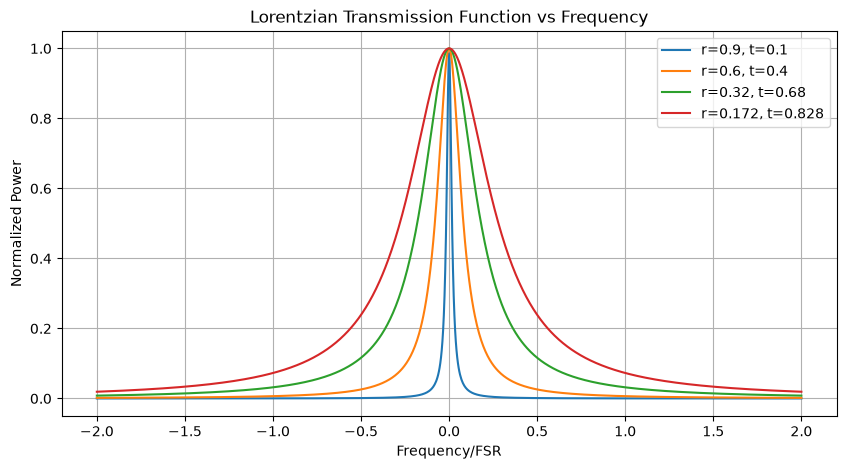

In [22]:
def lorentzian_peak_norm(f, f0, linewidth):
    return (linewidth)**2 / ((linewidth)**2 + 4 * (f - f0)**2)

tau_c_1 = -1 / (FSR * np.log(0.9 * 0.9)) 
tau_c_2 = -1 / (FSR * np.log(0.6 * 0.6))
tau_c_3 = -1 / (FSR * np.log(0.32 * 0.32))
tau_c_4 = -1 / (FSR * np.log(0.172 * 0.172))

linewidth_1 = 1/(2*np.pi*tau_c_1)
linewidth_2 = 1/(2*np.pi*tau_c_2)
linewidth_3 = 1/(2*np.pi*tau_c_3)
linewidth_4 = 1/(2*np.pi*tau_c_4)

# normalize linewidths to units of FSR, to match the f/FSR x-axis
linewidth_1_norm = linewidth_1 / FSR
linewidth_2_norm = linewidth_2 / FSR
linewidth_3_norm = linewidth_3 / FSR
linewidth_4_norm = linewidth_4 / FSR

f = np.linspace(-2, 2, 1000)
plt.figure(figsize=(10, 5))
plt.plot(f, lorentzian_peak_norm(f, 0, linewidth_1_norm), label='r=0.9, t=0.1')
plt.plot(f, lorentzian_peak_norm(f, 0, linewidth_2_norm), label='r=0.6, t=0.4')
plt.plot(f, lorentzian_peak_norm(f, 0, linewidth_3_norm), label='r=0.32, t=0.68')
plt.plot(f, lorentzian_peak_norm(f, 0, linewidth_4_norm), label='r=0.172, t=0.828')
plt.xlabel('Frequency/FSR')
plt.ylabel('Normalized Power')
plt.title('Lorentzian Transmission Function vs Frequency')
plt.legend()
plt.grid()
plt.show()

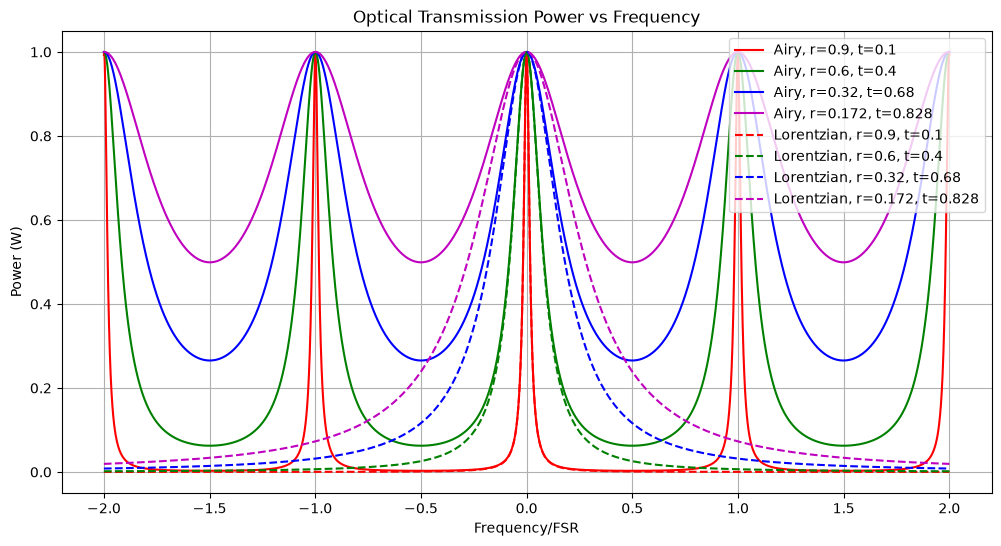

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(out1.x[0]/FSR, out1['trans'], 'r-', label='Airy, r=0.9, t=0.1')
plt.plot(out2.x[0]/FSR, out2['trans'], 'g-', label='Airy, r=0.6, t=0.4')
plt.plot(out3.x[0]/FSR, out3['trans'], 'b-', label='Airy, r=0.32, t=0.68')
plt.plot(out4.x[0]/FSR, out4['trans'], 'm-', label='Airy, r=0.172, t=0.828')
plt.xlabel('Frequency/FSR')
plt.ylabel('Power (W)')
plt.title('Optical Transmission Power vs Frequency')
f = np.linspace(-2, 2, 1000)
plt.plot(f, lorentzian_peak_norm(f, 0, linewidth_1_norm), 'r--', label='Lorentzian, r=0.9, t=0.1')
plt.plot(f, lorentzian_peak_norm(f, 0, linewidth_2_norm), 'g--', label='Lorentzian, r=0.6, t=0.4')
plt.plot(f, lorentzian_peak_norm(f, 0, linewidth_3_norm), 'b--', label='Lorentzian, r=0.32, t=0.68')
plt.plot(f, lorentzian_peak_norm(f, 0, linewidth_4_norm), 'm--', label='Lorentzian, r=0.172, t=0.828')
plt.legend()
plt.grid()
plt.show()

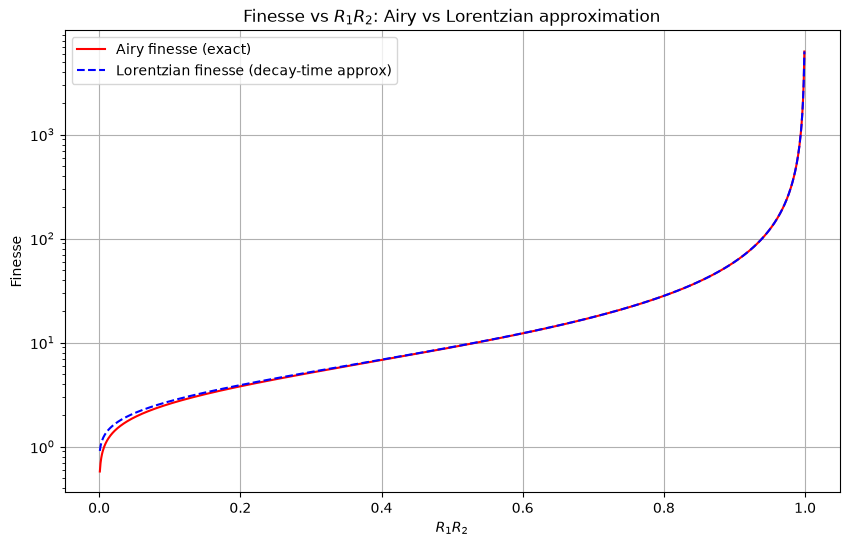

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def airy_finesse(R1R2):
    r1r2 = np.sqrt(R1R2)
    return np.pi * np.sqrt(r1r2) / (1 - r1r2)

def lorentzian_finesse(R1R2):
    return -2 * np.pi / np.log(R1R2)

R1R2 = np.linspace(0.001, 0.999, 1000)

F_airy = airy_finesse(R1R2)
F_lorentz = lorentzian_finesse(R1R2)

plt.figure(figsize=(10, 6))
plt.plot(R1R2, F_airy, 'r-', label='Airy finesse (exact)')
plt.plot(R1R2, F_lorentz, 'b--', label='Lorentzian finesse (decay-time approx)')
plt.xlabel(r'$R_1 R_2$')
plt.ylabel('Finesse')
plt.yscale('log')
plt.title('Finesse vs $R_1R_2$: Airy vs Lorentzian approximation')
plt.legend()
plt.grid()
plt.show()

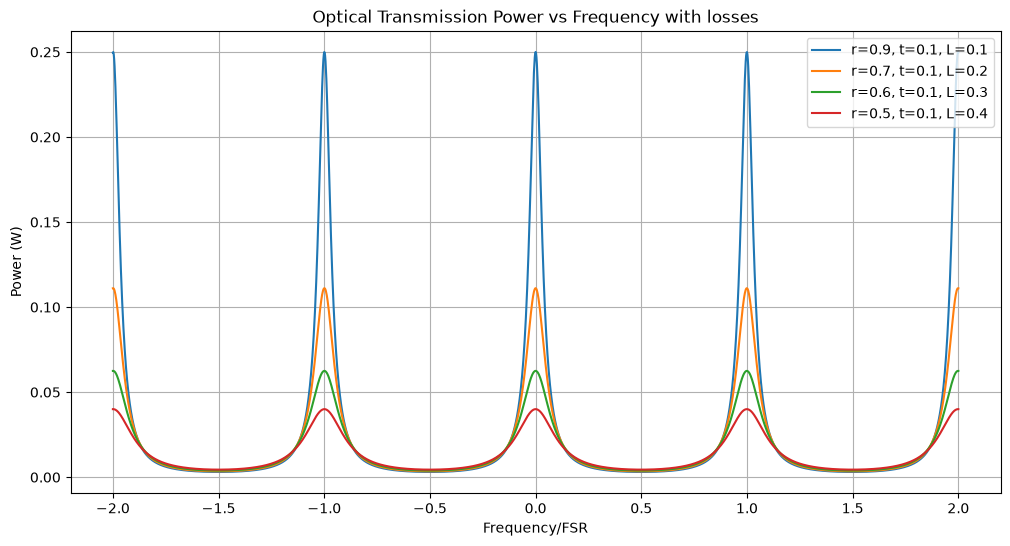

In [25]:
import finesse
from finesse import Model
from finesse.analysis.actions import Xaxis
import matplotlib.pyplot as plt

model1 = Model()
model1.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.8 T=0.1 L=0.1       # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.8 T=0.1 L=0.1        # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out1 = model1.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

model2 = Model()
model2.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.7 T=0.1 L=0.2       # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.7 T=0.1 L=0.2        # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out2 = model2.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

model3 = Model()
model3.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.6 T=0.1 L=0.3       # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.6 T=0.1 L=0.3        # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out3 = model3.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

model4 = Model()
model4.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.5 T=0.1 L=0.4       # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.5 T=0.1 L=0.4        # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out4 = model4.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

plt.figure(figsize=(12, 6))
plt.plot(out1.x[0]/FSR, out1['trans'], label='r=0.9, t=0.1, L=0.1')
plt.plot(out2.x[0]/FSR, out2['trans'], label='r=0.7, t=0.1, L=0.2')
plt.plot(out3.x[0]/FSR, out3['trans'], label='r=0.6, t=0.1, L=0.3')
plt.plot(out4.x[0]/FSR, out4['trans'], label='r=0.5, t=0.1, L=0.4')
plt.xlabel('Frequency/FSR')
plt.ylabel('Power (W)')
plt.title('Optical Transmission Power vs Frequency with losses')
plt.legend()
plt.grid()
plt.show()